Clean up my method for running MCMC

In [92]:
import eMCMC
import importlib
import eplots
Plotter = eplots.Plotting()
import estats
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Math
from scipy.stats import mode

In [2]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

In [3]:
# Plotting
def compare_fits(alternative_fits, samples, my_UVLF, data_label = 'Bouwens+21', Plotting = None, title = 'Fit comparison'):
    """
    samples [ndarray]: Results from MCMC
    my_UVLF: MCMC_UVLF object
    piecewise_flags [2darray]: whether the fits are piecewise or linear in epsilon & sigma
    """
    # Figure out how many subplots to make
    zs = [dat[0] for dat in my_UVLF.data]
    nz = len(zs)
    fig, ax = plt.subplots(1, nz, sharey = True)
    fig.set_size_inches(3.5*nz, 3)
    plt.subplots_adjust(wspace = 0.1)

    if Plotting is None:
        Plotting = eplots.Plotting()

    for i, (dat, z) in enumerate(zip(my_UVLF.data, zs)):
    
        # Decompose the data
        zdat = dat[0]
        zerr = dat[1]
        xdat = dat[2]
        ydat = dat[3]
        yerr = dat[4] 
        xerr = dat[5]   

        yerr = np.fmax(yerr, ydat* my_UVLF.MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above

        # Plot my best fit
        best_fit = np.average(samples, axis = 0)
        chi2 = -2*my_UVLF.log_like(best_fit)
        ax[i].plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit)), label = f'My fit (linear), $\chi^2 = {chi2:.0f}$', 
                   zorder = 1)
        
        # Plot other fit options
        for params, label, flags, ls in zip(fits, labels, piecewise_flags, ['--', 'dotted']):
            chi2 = -2*my_UVLF.log_like(params, piecewise_eps = flags[0], piecewise_sig = flags[1])
            ax[i].plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, params, piecewise_eps = flags[0], 
                                                           piecewise_sig = flags[1])), label = f'{label}, $\chi^2 = {chi2:.0f}$', 
                       linestyle = ls)
    
        
        ax[i].errorbar(xdat, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
                       color = Plotting.navy, label = data_label)
        
        ax[i].invert_xaxis()
        ax[i].set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)
        ax[i].set_xlim(np.max(xdat)+0.25, np.min(xdat)-0.25)
        ax[i].set_title(f'$z \simeq {int(zdat)}$')
        ax[i].xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

    ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
    fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')
    fig.text(.5, 1.1, title, ha = 'center', fontsize = 20)
    leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    return fig

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_2523/3366703092.py:33: SyntaxWarning: invalid escape sequence '\c'
  ax[i].plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit)), label = f'My fit (linear), $\chi^2 = {chi2:.0f}$',
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_2523/3366703092.py:40: SyntaxWarning: invalid escape sequence '\c'
  piecewise_sig = flags[1])), label = f'{label}, $\chi^2 = {chi2:.0f}$',
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_2523/3366703092.py:50: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


In [94]:
param_data = [{'label': r"$\alpha$", 'fit': True, 'value': None, 'start': 0.6, 'scale': 1, 'lower': 0, 'upper': 4},
              {'label': r"$d\alpha/dz$", 'fit': True, 'value': None, 'start': 0.01, 'scale': 100, 'lower': -0.5, 'upper': 0.5},
              {'label': r"$d\alpha/dM_{h}$", 'fit': False, 'value': 0, 'start': None, 'scale': None, 'lower': None, 'upper': None},
              {'label': r"$\beta$", 'fit': True, 'value': None, 'start': -0.5, 'scale': 1, 'lower': -1, 'upper': 0},
              {'label': r"$d\beta/dz$", 'fit': True, 'value': None, 'start': 0.01, 'scale': 100, 'lower': -0.5, 'upper': 0.5},
              {'label': r"$d\beta/dM_{h}$", 'fit': False, 'value': 0, 'start': None, 'scale': None, 'lower': None, 'upper': None},
              {'label': r'$\log(M_c)$', 'fit': True, 'value': None, 'start': 12, 'scale': 1, 'lower': 9, 'upper': 16},
              {'label': r'$d\log(M_c)/dz$', 'fit': True, 'value': None, 'start': 0.01, 'scale': 100, 'lower': -0.5, 'upper': 0.5},
              {'label': r'$d\log(M_c)/dM_{h}$', 'fit': False, 'value': 0, 'start': None, 'scale': None, 'lower': None, 'upper': None},
              {'label': r"$\log(\epsilon_0)$", 'fit': True, 'value': None, 'start': -1, 'scale': 1, 'lower': -1, 'upper': 1},
              {'label': r'$d\log(\epsilon_0)/dz$', 'fit': True, 'value': None, 'start': 0.01, 'scale': 100, 'lower': -0.5, 'upper': 0.5},
              {'label': r'$d\log(\epsilon_0)/dM_{h}$', 'fit': False, 'value':0, 'start': 0.01, 'scale': 100, 'lower': -1, 'upper': 1},
              {'label': r'$\sigma_{\rm{UV}, 0}$', 'fit': True, 'value': None, 'start': 0.5, 'scale': 1, 'lower': 0, 'upper': 3},
              {'label': r'$d\sigma_{\rm{UV}}/dz$', 'fit': True, 'value': None, 'start': 0.01, 'scale': 100, 'lower': -0.5, 'upper': 0.5},
              {'label': r'$d\sigma_{\rm{UV}}/dM_{h}$', 'fit': False, 'value': 0, 'start': None, 'scale': None, 'lower': None, 
               'upper': None}
             ]

In [102]:
importlib.reload(eMCMC)

<module 'eMCMC' from '/Users/eb35267/Desktop/research/escripts/eMCMC.py'>

In [103]:
# Initalize class
my_UVLF = eMCMC.UVLF(datHST, param_data)

In [104]:
# Get initial positions for all the walkers by running a short MCMC
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [105]:
# Run MCMC
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 

State([[ 0.66844742  1.546185   -0.09097672 27.88563332 12.24961374  7.88137252
  -0.81788193 -2.28439281  0.6067072   1.63243819]
 [ 0.69966626  0.11771592 -0.83374072 30.04843976 11.92176857  4.71529138
  -0.9799705  -4.11414872  0.55600002 -7.29220027]
 [ 0.57963065  0.6103169  -0.29917682 44.595971   12.34661754 10.98275642
  -0.90559491 -0.83219537  0.73959854 -1.17387618]
 [ 0.75714464  4.82088593 -0.98603403 45.69205626 12.16415523  8.123568
  -0.72031342  3.22867872  0.42533332 -8.51672887]
 [ 0.69919817  1.04022066 -0.19297306 41.49504712 11.88853028  3.57605055
  -0.93067369 -3.308887    0.5759226  -5.03523865]
 [ 0.68020307  1.39605936 -0.50259941 38.95275759 11.93825045  5.649541
  -0.95572753 -1.62240747  0.56712079 -7.66391017]
 [ 0.79538096  4.06876375 -0.06050191 46.99988756 12.01596707  4.64208817
  -0.76183179  3.00930185  0.58588137 -6.64052145]
 [ 0.90451962  9.32217477 -0.52939643 39.08522899 12.12602015  3.59538996
  -0.52522357  5.99045516  0.33007402 -7.55000846

In [106]:
# Get a list of all of the parameter values along the chain
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True) # No need to deal with scale here, it will be taken care of in the wrapper

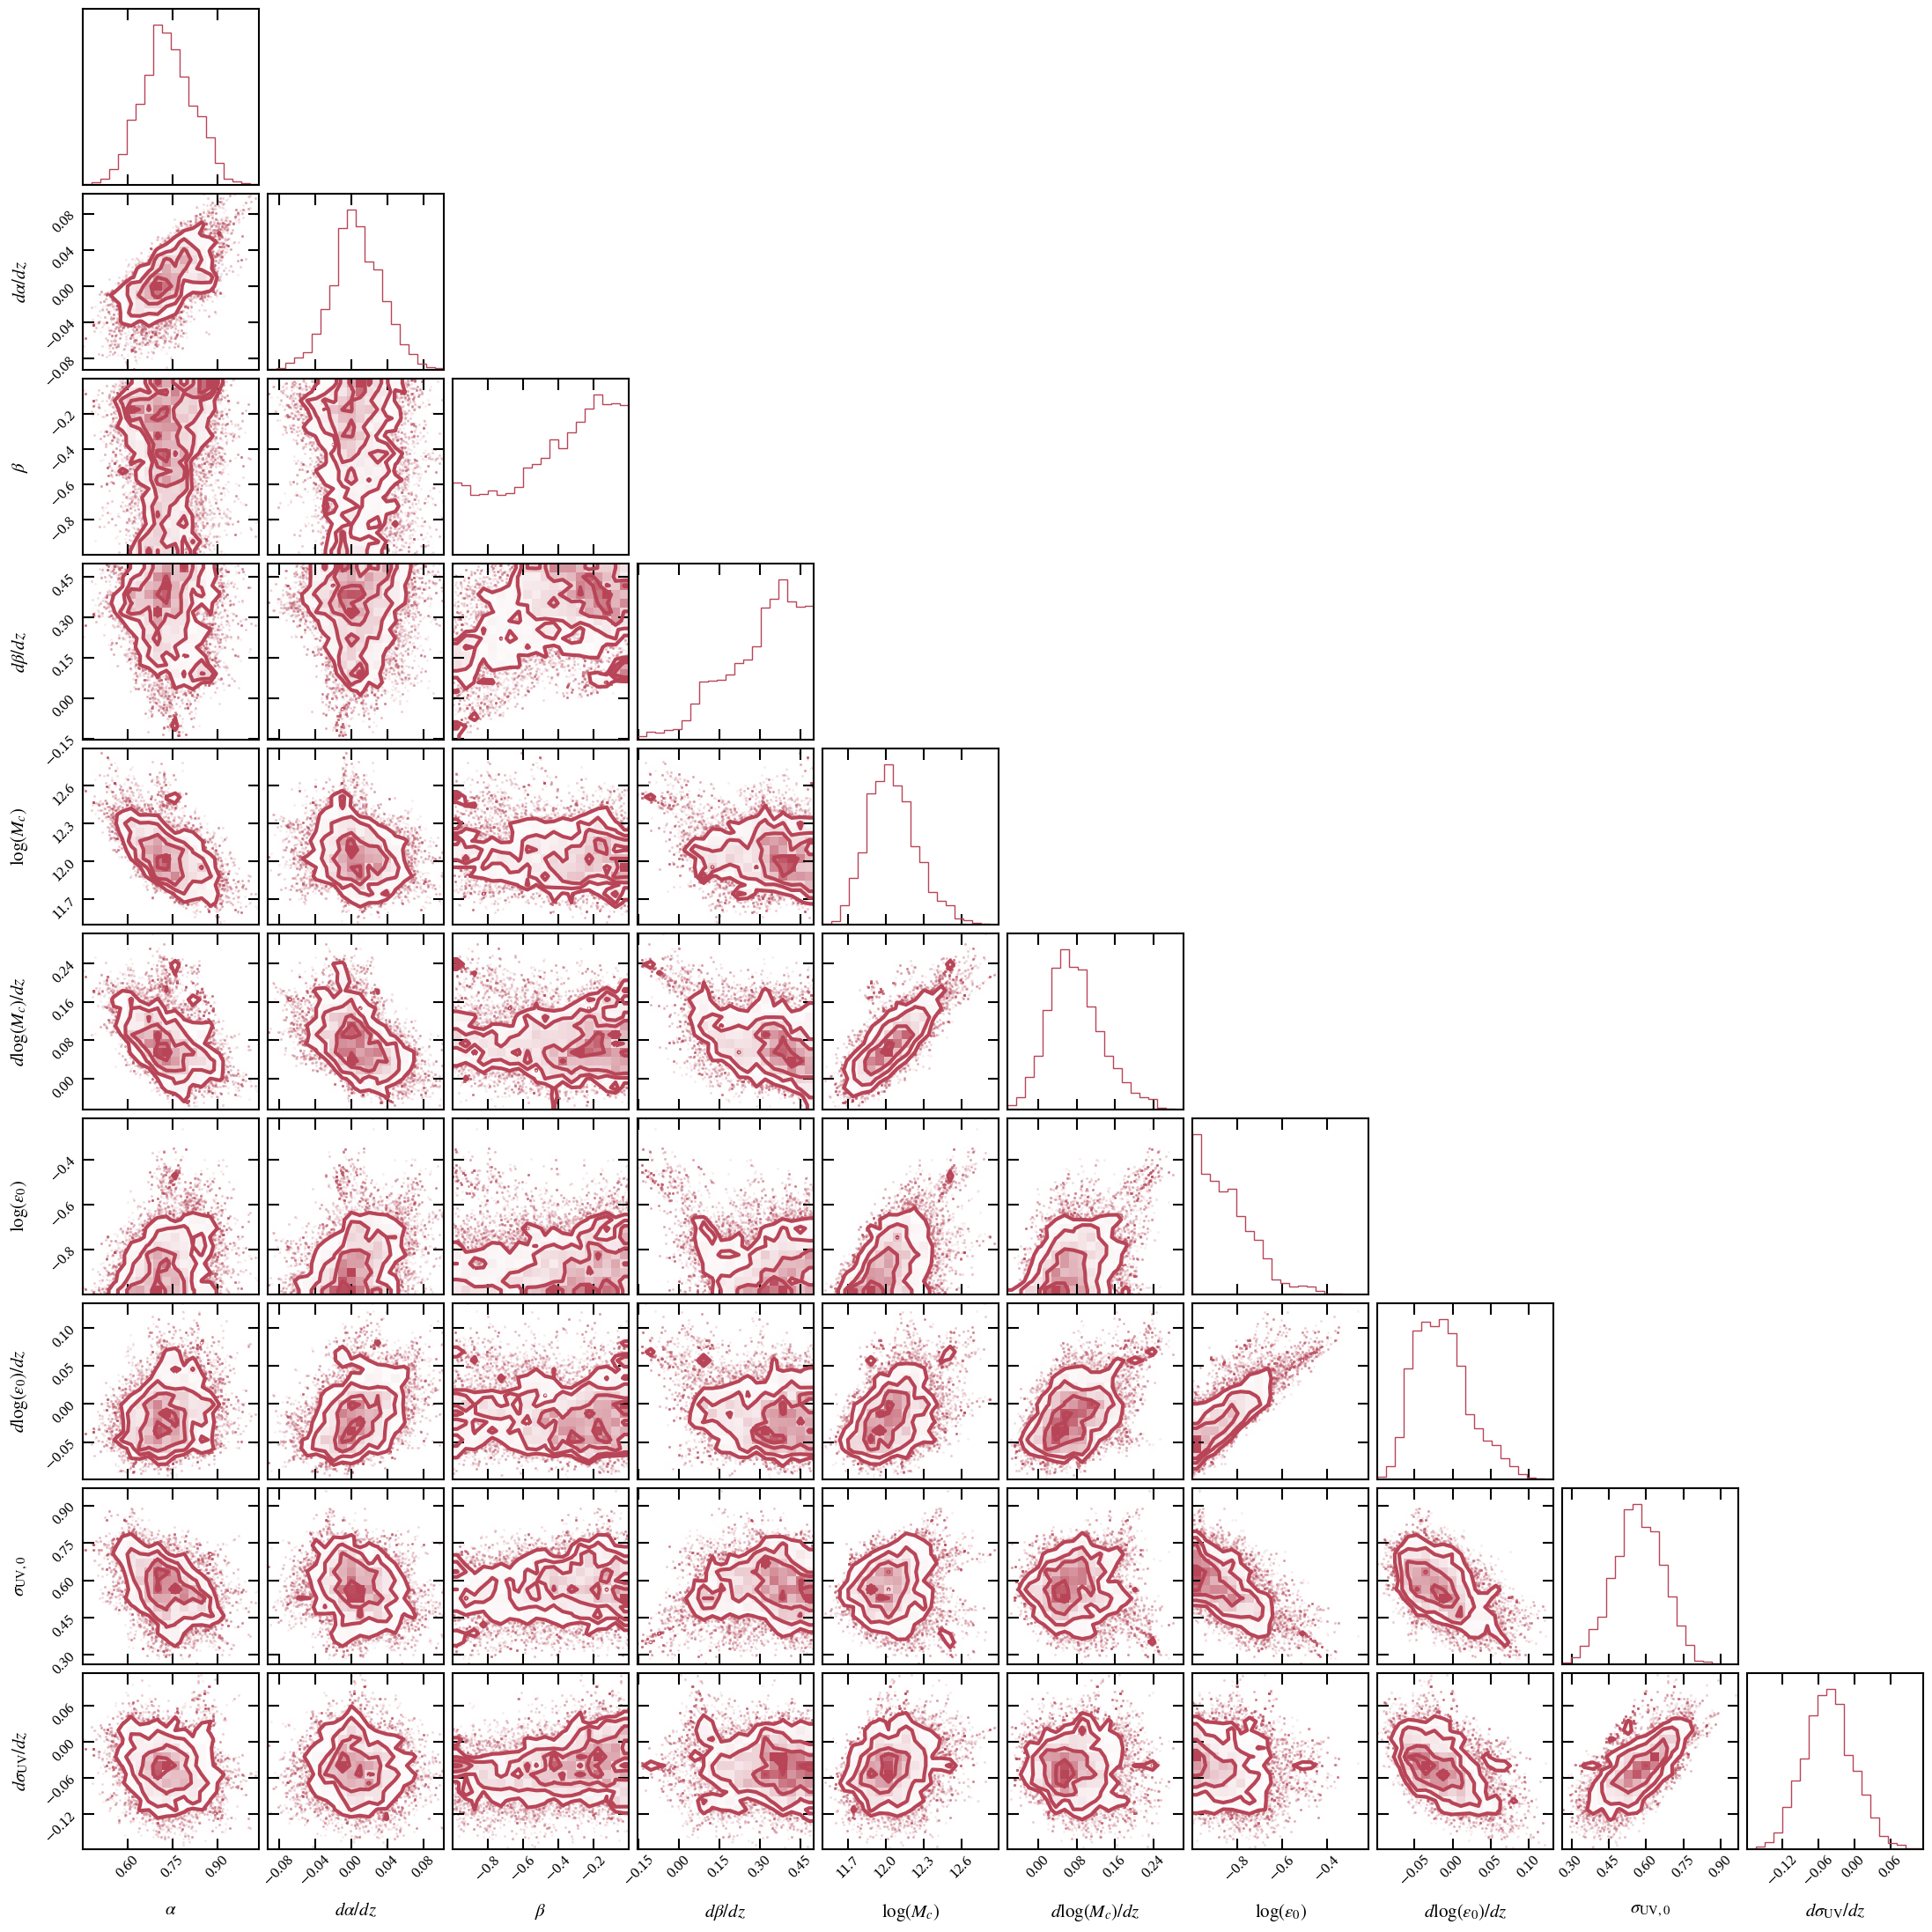

In [107]:
# Time evolution plot
corner_plot = Plotter.plot_corner(samples, param_data) # [1::2] means start at index 1 & step by 2s-- so, odd numbers

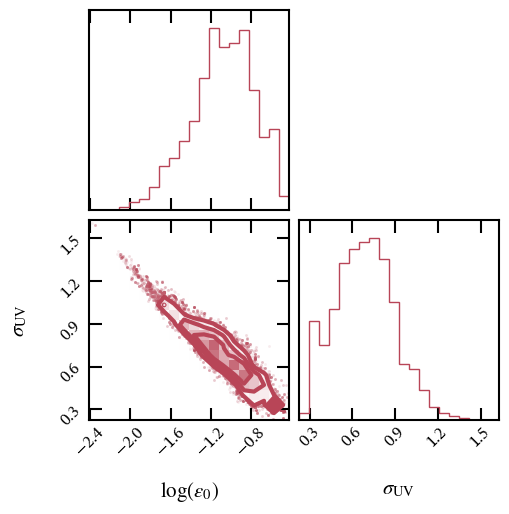

In [87]:
# # Plot epsilon & sigma central values
# corner_plot = Plotter.plot_corner(samples[:,[6,8]], [labels[6], labels[8]])
# #corner_plot.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/corner_sig_eps.png', bbox_inches='tight')

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


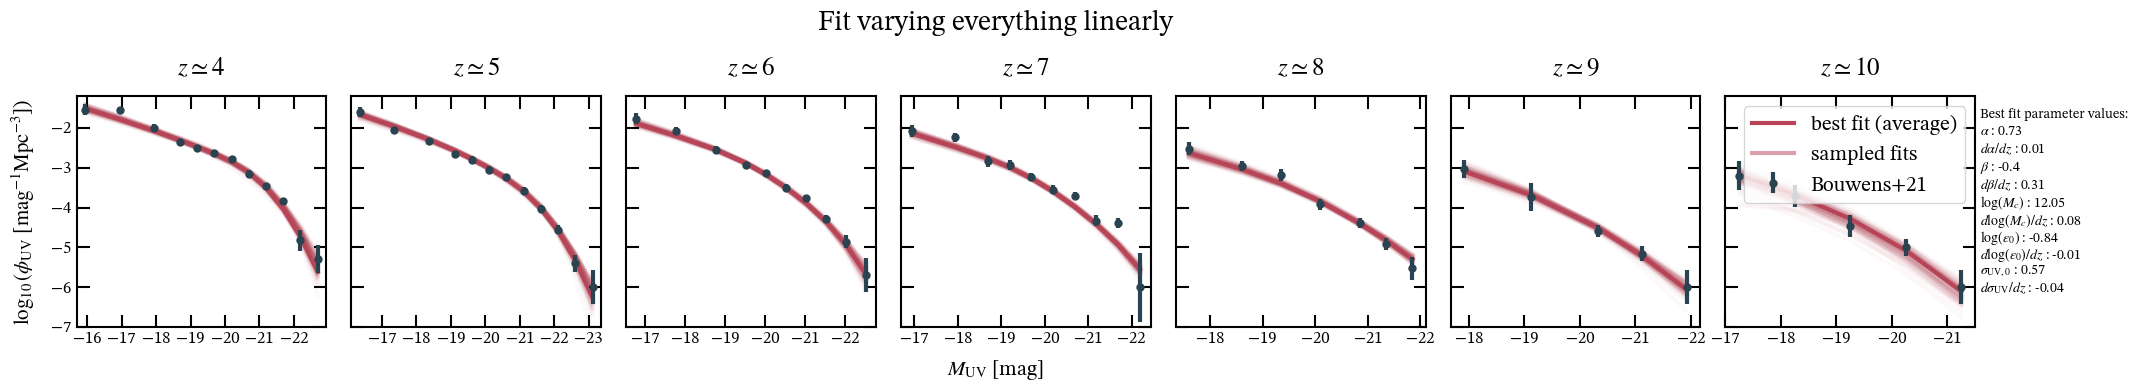

In [108]:
# Look at the fit over time
comp_fig = Plotter.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'Fit varying everything linearly', nsamples = 100)
#comp_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Bouwens_over_time.png', bbox_inches='tight')

In [42]:
# def UVLF_fit_single_z(samples, z, my_UVLF, bf_type = 'average', data_label = 'Bouwens+21', Plotting = None, 
#                        nsamples = 100, truths = None, title = 'UVLF data vs. MCMC fit'):
#     """
#     samples [ndarray]: Results from MCMC
#     my_UVLF: MCMC_UVLF object
#     """
#     fig, ax = plt.subplots()

#     if Plotting is None:
#         Plotting = eplots.Plotting()

#     assert bf_type in ['average', 'mode'], 'The best fit type must be either average or mode'

#     # Choose random samples from the MCMC chain
#     inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

#     all_data = my_UVLF.data
#     zs = np.array([all_dat[0] for all_dat in all_data])
#     ind = np.where(zs == z)[0].item() # The .item() removes the brackets
    
#     # Decompose the data
#     zdat = all_data[ind][0]
#     zerr = all_data[ind][1]
#     xdat = all_data[ind][2]
#     ydat = all_data[ind][3]
#     yerr = all_data[ind][4] 
#     xerr = all_data[ind][5]   

#     yerr = np.fmax(yerr, ydat* my_UVLF.MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above

#     # Plot each sample from the chain
#     for ind in inds:
#         sample = samples[ind]
#         ax.plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, sample)), alpha=nsamples/3500, color = Plotting.red, 
#                    zorder = 0)
    
        
#     if truths is not None: # Plot the true curve if one is known. Otherwise, plot the best fit
#         ax.plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, truths)), color = Plotting.red, label = 'true UVLF', 
#                    zorder = 1)
#     else: # Options for how to define best fit
#         if bf_type == 'mode':
#             best_fit = mode(samples, axis = 0).mode 
#         else:
#             best_fit = np.average(samples, axis = 0)
            
#     ax.plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit)), color = Plotting.red, 
#                label = f'best fit ({bf_type})', zorder = 1)
    
#     ax.plot([0], [0], color = Plotting.red, alpha = 0.5, label = 'sampled fits') # Create the label for the samples
#     ax.errorbar(xdat, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
#                    color = Plotting.navy, label = data_label)
        
#     ax.invert_xaxis()
#     ax.set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)
#     ax.set_xlim(np.max(xdat)+0.25, np.min(xdat)-0.25)
#     ax.set_title(f'$z \simeq {int(zdat)}$')
#     ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

#     ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
#     ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
#     fig.text(.5, 1, title, ha = 'center', fontsize = 20)
#     ax.legend()

#     return fig

<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_2523/4129549448.py:57: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'$z \simeq {int(zdat)}$')


In [109]:
# prior_effect = UVLF_fit_single_z(samples, 9, my_UVLF, title = '')

# #prior_effect.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/bad_fits_prior_z9.png')

In [539]:
jm_fits = [[12.03, 0.03, .61, -0.01, -1.91, 0.08,  
          -0.835644487121554, -0.8813262539539082, -0.878982150926344, -1.0135562584726614, -1.1280360370537728, -1.1736330772706727,
            -1.170950067781292,
           0.65, -0.03
          ], 
          [11.84, -0.02, .74, .03, -1.76, -0.02,  -1.08, -0.07,
           0.7386363636363633, 0.7386363636363633, 0.7954545454545454, 0.6931818181818183, 0.43181818181818166, 0.4545454545454546, 
           0.5340909090909092
          ]
          ]
jm_piecewise_flags = [[True, False], [False, True]]
jm_labels = [r'Muñoz+23 HST($\epsilon_*$)', r'Muñoz+23 HST($\sigma_{\rm{UV}}$)']

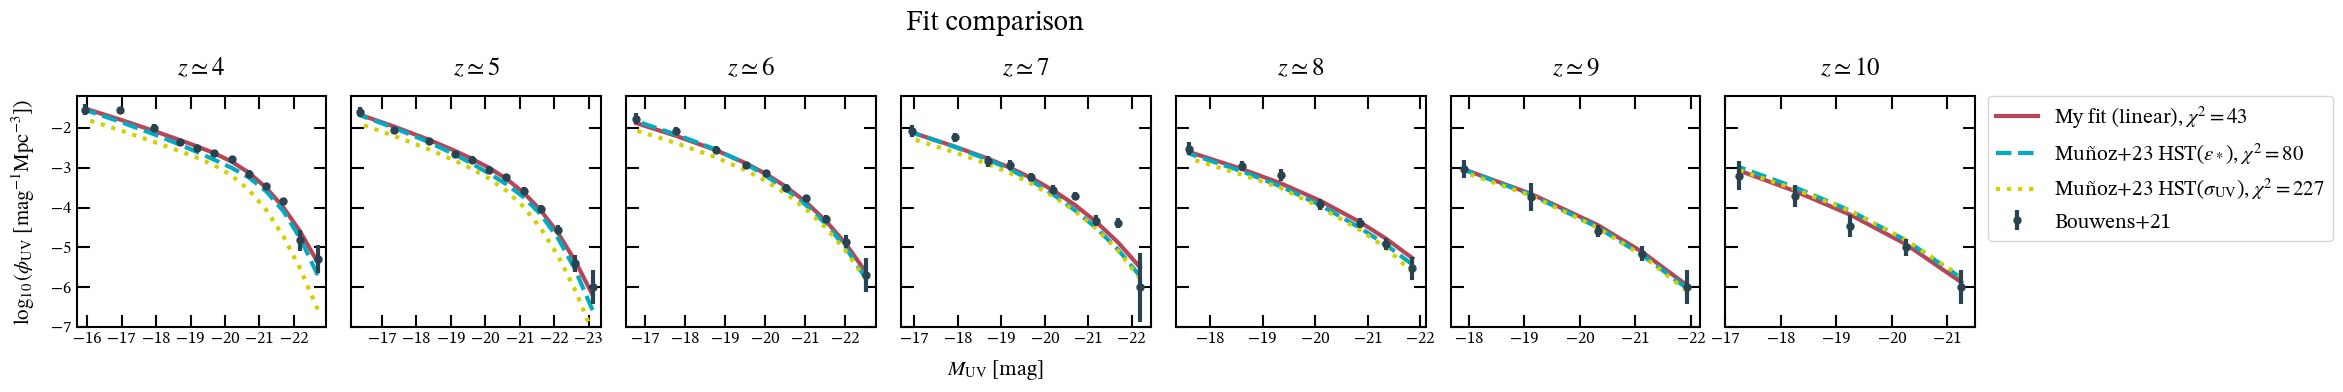

In [546]:
compare_fig = compare_fits(jm_fits, jm_piecewise_flags, jm_labels, samples, my_UVLF, Plotting = Plotter)
#compare_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/fit_comparison_muñoz.png', bbox_inches='tight')

In [541]:
best_fit = np.average(samples, axis = 0)
best_fit[1::2] = best_fit[1::2] / 100

In [549]:
best_fit

array([ 1.18079895e+01,  2.17551041e-02,  6.37281656e-01, -1.84008272e-02,
       -1.23247424e+00,  2.17283780e-01, -1.20684281e+00, -9.70658785e-02,
        7.78995635e-01, -1.17025432e-02])

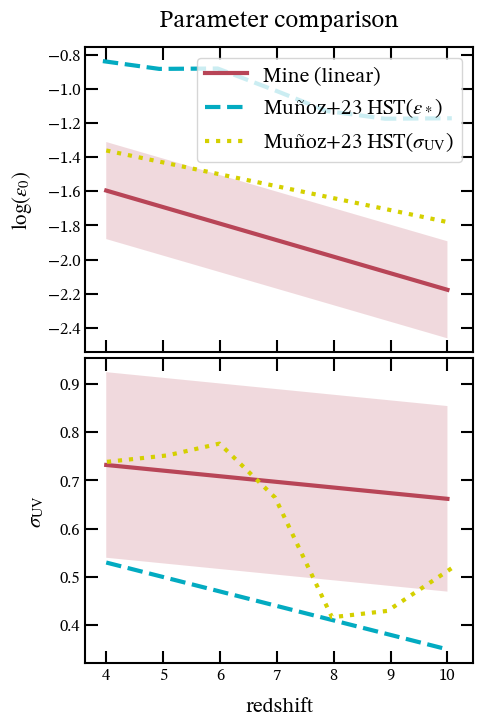

In [548]:
jm_epsilon = np.array([3.940719611387257, -0.835644487121554,
4.9321057388160865, -0.8813262539539082,
5.95882286488929, -0.878982150926344,
7.01536375960235, -1.0135562584726614,
7.873220741075462, -1.1280360370537728,
8.901717126073203, -1.1736330772706727,
10.07687528242205, -1.170950067781292]).reshape(-1, 2)

jm_sigma = np.array([4.012793027097318, 0.738633301702222,
5.076793308262749, 0.7520120901135203,
5.992408533370822, 0.7764734825853163,
6.969036656943029, 0.6646867934254148,
7.96956384212561, 0.41658173127613995,
8.946965170632271, 0.4297965065195233,
10.135170280813973, 0.522955985894868
]).reshape(-1, 2)


fig, ax = plt.subplots(2, 1, sharex = True)
fig.set_size_inches(5, 8)
plt.subplots_adjust(hspace=0.02)
ax[0].plot(redshiftsBouw21, best_fit[6] + (best_fit[7]*redshiftsBouw21), label = 'Mine (linear)')
sigeps = np.std(samples[:,0])
ax[0].fill_between(redshiftsBouw21,  best_fit[6]-sigeps + (redshiftsBouw21*best_fit[7]), 
                   best_fit[6]+sigeps + (redshiftsBouw21*best_fit[7]), alpha = 0.2)
ax[0].plot(jm_epsilon[:,0], jm_epsilon[:,1], linestyle = '--', label = r'Muñoz+23 HST($\epsilon_*$)')
ax[0].plot(redshiftsBouw21,( -1.08 + (-0.07*redshiftsBouw21)), label = r'Muñoz+23 HST($\sigma_{\rm{UV}}$)', linestyle = 'dotted')
ax[0].set_ylabel(labels[6])
ax[0].legend()
ax[0].set_title(r'Parameter comparison')

ax[1].plot(redshiftsBouw21, best_fit[8] + (best_fit[9]*redshiftsBouw21))
sigsig = np.std(samples[:,8])
ax[1].fill_between(redshiftsBouw21,  best_fit[8]-sigsig + (redshiftsBouw21*best_fit[9]), 
                   best_fit[8]+sigsig + (redshiftsBouw21*best_fit[9]), alpha = 0.2)
ax[1].plot(redshiftsBouw21,(.65 + (-0.03*redshiftsBouw21)), linestyle = '--')
ax[1].plot(jm_sigma[:,0], jm_sigma[:,1], linestyle = 'dotted')
ax[1].set_ylabel(labels[8])
ax[1].set_xlabel('redshift')

fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Muñoz+23_comp_errors.png', bbox_inches='tight')

In [547]:
save_dir

'/Users/eb35267/Desktop/figures'